In [2]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from robust_svgp import LMCInducingPointsBase
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50}, method="L-BFGS-B")
    plt.plot(res["loss_history"])
    plt.show()

def get_kernel():
    return gpf.kernels.Matern32(active_dims=[0])

2026-09-25 11:17:22.716207: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 11:17:22.717527: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-25 11:17:22.743165: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-25 11:17:22.743861: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-25 11:17:23.354991: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

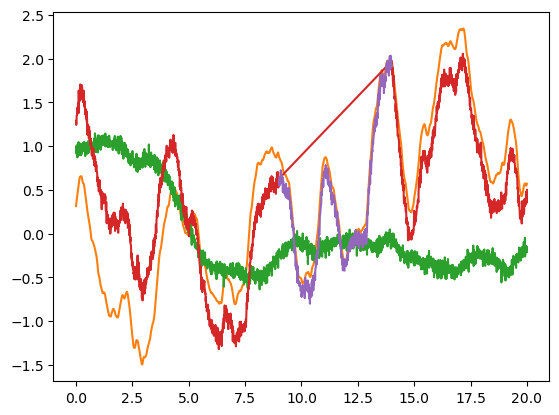

In [3]:
prop = 0.8
xs = np.linspace(0, 20, 2000).reshape(-1, 1)
xt = np.linspace(0, 20, 2000).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(xs.flatten()), gpf.kernels.Matern32(lengthscales=5, variance=1)(xs))
f2 = np.random.multivariate_normal(np.zeros_like(xs.flatten()), gpf.kernels.Matern32(lengthscales=1, variance=1)(xs))

test_size = int(int(len(xt)) * 0.25)
start = int(int(len(xt)) * 0.45)
ys = (f1 + np.random.normal(0, 0.05, len(xs))).reshape(-1, 1)
yt = (f1 + f2 + np.random.normal(0, 0.05, len(xt))).reshape(-1, 1)
yt_train_full = np.concatenate((yt[:start], yt[start+test_size:]))
xt_train_full = np.concatenate((xt[:start], xt[start+test_size:]))
yt_test_full = yt[start:start + test_size]
xt_test_full = xt[start:start + test_size]

x = np.vstack((np.hstack((xs, np.zeros_like(xs))), np.hstack((xt_train_full, np.ones_like(xt_train_full)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt_train_full, np.ones_like(yt_train_full)))))

plt.plot(xs, f1)
plt.plot(xs, f2)
plt.plot(xs, ys)
plt.plot(xt_train_full, yt_train_full)
plt.plot(xt_test_full, yt_test_full)

In [4]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel() 

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg 
model3 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(model3)
optimize(model3)
gpf.utilities.print_summary(model3)

NameError: name 'X' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xs.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xt_test_full, np.ones_like(Xt_test_full)))
fmean, fvar = model3.predict_f(Xplot)
fmean_tst, fvar_tst = model3.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(Xs, ys, "kx")
plt.plot(Xt_train_full, yt_train_full, "bx")
plt.plot(Xt_test_full, yt_test_full, "gx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

cmogp_mse = mean_squared_error(yt_test_full, fmean_tst)
cmogp_mse

NameError: name 'Xs' is not defined

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = TransferLikelihood(
    source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
)
model4 = gpf.models.VGP(data=(X, y), kernel=kern, likelihood=lik)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model4.training_loss,
    model4.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model4)

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.4188                                               │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()     

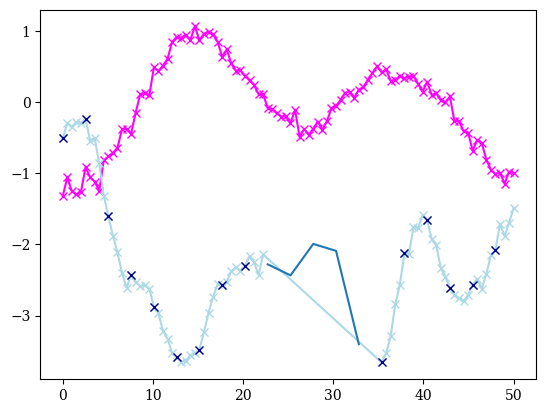

In [ ]:
yt_ds = [y for i, y in enumerate(yt) if i % 5 == 0]
Xt_ds = [x for i, x in enumerate(Xt) if i % 5 == 0]

test_size = int(int(len(Xt_ds)) * 0.25)
start = int(int(len(Xt_ds)) * 0.45)

yt_train_ds = np.concatenate((yt_ds[:start], yt_ds[start+test_size:]))
Xt_train_ds = np.concatenate((Xt_ds[:start], Xt_ds[start+test_size:]))
yt_test_ds= yt_ds[start:start + test_size]
Xt_test_ds = Xt_ds[start:start + test_size]

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt_train_ds, np.ones_like(Xt_train_ds)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt_train_ds, np.ones_like(yt_train_ds)))))

plt.plot(Xs, ys, marker="x", color="magenta")
plt.plot(Xt_train_full, yt_train_full, marker="x", color="lightblue")
plt.plot(Xt_train_ds, yt_train_ds, marker="x", color="darkblue", lw=0)
plt.plot(Xt_test_ds, yt_test_ds)

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.ke

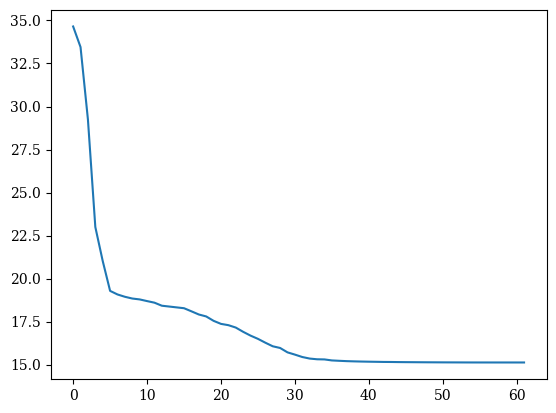

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 70.87861                        │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 9060.52251                      │
├───────────────

In [ ]:
output_dim = 2  # number of outputs
rank = 1  # rank of w

# base kernel
k = get_kernel() 

# coregion kernel
coreg = gpf.kernels.coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg 
model1 = conditionalmogp((x, y), kernel=kern, likelihood=transferlikelihood(source=gpf.likelihoods.gaussian(), target=gpf.likelihoods.gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, true)
#gpf.set_trainable(m.likelihood.source.variance, false)

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)

In [ ]:
# this likelihood switches between gaussian noise with different variances for each f_i:
output_dim = 2  # number of outputs
rank = 1  # rank of w

# base kernel
k = get_kernel()

# coregion kernel
coreg = gpf.kernels.coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = transferlikelihood(
    source=gpf.likelihoods.gaussian(), target=gpf.likelihoods.gaussian()
)

model2 = gpf.models.vgp(data=(x, y), kernel=kern, likelihood=lik)
# fit the covariance function parameters
gpf.optimizers.scipy().minimize(
    model2.training_loss,
    model2.trainable_variables,
    method="l-bfgs-b",
)
gpf.utilities.print_summary(model2)

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.26195                                              │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()     

<atmodel.ConditionalMOGP object at 0x7f1bafd5a8d0> 0.05033144939448684
<gpflow.models.vgp.VGP object at 0x7f1c281a3750> 0.1434572620446523


/tmp/ipykernel_7802/3771873084.py:26: RuntimeWarning: invalid value encountered in sqrt
  (fmean[:,0] - 2 * np.sqrt(fvar[:,0])),
/tmp/ipykernel_7802/3771873084.py:27: RuntimeWarning: invalid value encountered in sqrt
  (fmean[:,0] + 2 * np.sqrt(fvar[:,0])),
/tmp/ipykernel_7802/3771873084.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncols=2, fontsize=15, loc="lower center")


<atmodel.ConditionalMOGP object at 0x7f1c2a3d4a50> 0.36999361792963675
<gpflow.models.vgp.VGP object at 0x7f1bb43f9310> 0.44588067954454125


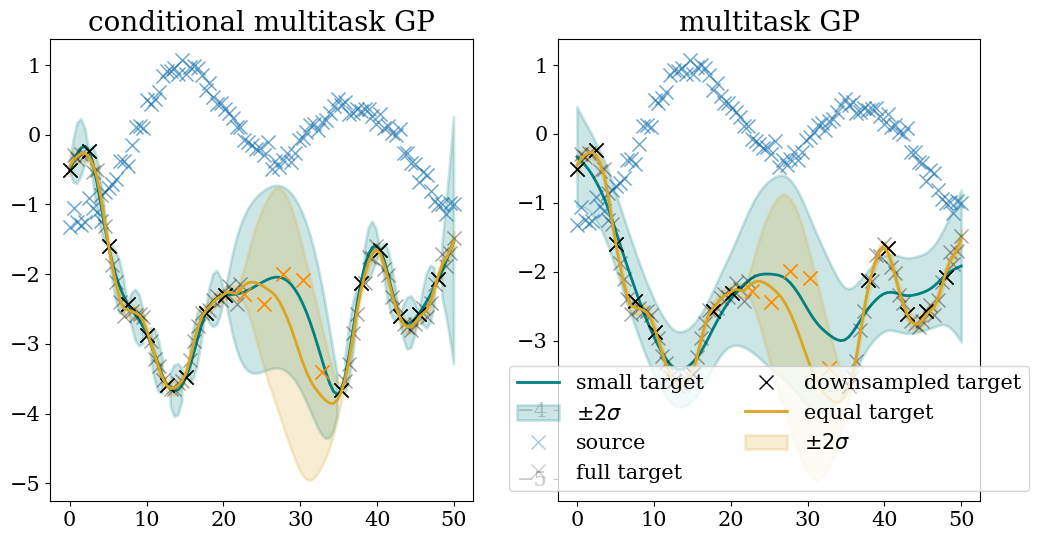

In [ ]:
import matplotlib as mpl 
colors = mpl.color_sequences["Set1"]
plt.rcParams["font.family"] = "serif"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ms = 10
for ax in (ax1, ax2):
    continue 

names = ["small target", "small target", "equal target", "equal target"]

for m, ax, pcolor, name, (Xtest, ytest) in zip([model1, model2, model3, model4], (ax1, ax2, ax1, ax2), ("teal", "teal", "goldenrod", "goldenrod"), names, \
    [(Xt_test_ds, yt_test_ds), (Xt_test_ds, yt_test_ds), (Xt_test_full, yt_test_full), (Xt_test_full, yt_test_full)]):   
    Xall = Xs.reshape(-1, 1)
    Xplot = np.hstack((Xall, np.ones_like(Xall)))
    Xtst = np.hstack((Xtest, np.ones_like(Xtest)))
    fmean, fvar = m.predict_f(Xplot)
    fmean_tst, fvar_tst = m.predict_f(Xtst)
    ax.plot(Xs, ys, color="C0", marker="x", ms=ms, lw=0, alpha=0.4, label="source" if pcolor == "goldenrod" else "")
    ax.plot(Xt_train_full, yt_train_full, color="black", marker="x", ms=ms, lw=0, alpha=0.2, label="full target" if pcolor == "goldenrod" else "")
    ax.plot(Xt_train_ds, yt_train_ds, color="black", marker="x", ms=ms, lw=0, label="downsampled target" if pcolor == "goldenrod" else "")
    ax.plot(Xt_test_ds, yt_test_ds, color="darkorange", marker="x", lw=0, ms=ms)
    ax.plot(Xall, fmean[:,0], color=pcolor, label=name, lw=2)
    ax.fill_between(
        Xall[:, 0],
        (fmean[:,0] - 2 * np.sqrt(fvar[:,0])),
        (fmean[:,0] + 2 * np.sqrt(fvar[:,0])),
        lw=2,
        color=pcolor,
        alpha=0.2,
        label = "$\pm 2\sigma$"
    )
    ax.tick_params(axis="both", labelsize=15)
    if ax == ax1:
        ax.set_title("conditional multitask GP", fontsize=20)
    else:
        ax.set_title("multitask GP", fontsize=20)
    plt.legend(ncols=2, fontsize=15, loc="lower center")
    mse = mean_squared_error(ytest, fmean_tst[:,0])
    print(m, mse)

(150,)


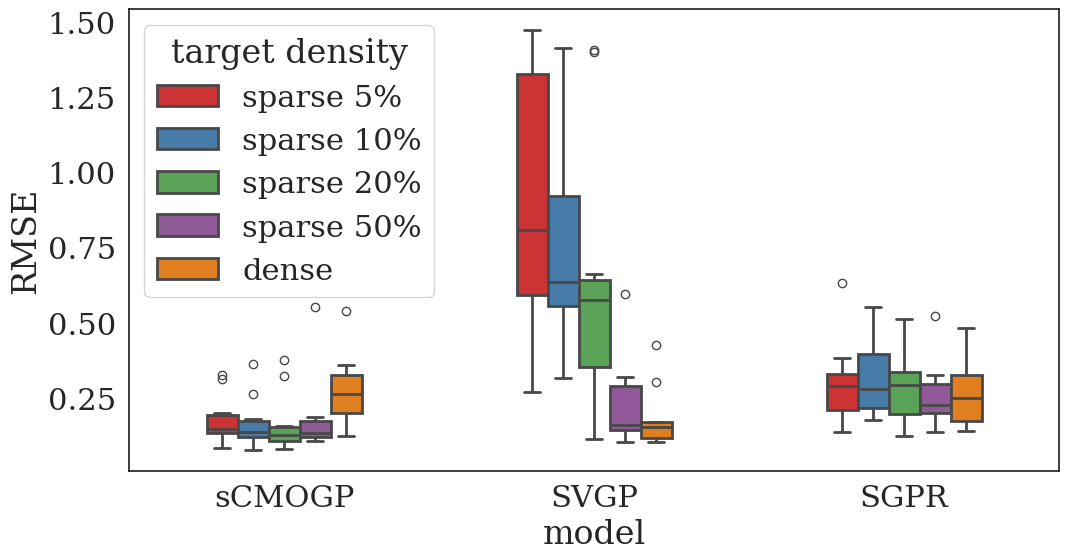

tests 5%
SGPR/SCMOGP WilcoxonResult(statistic=7.0, pvalue=0.037109375) SVGP/SCMOGP WilcoxonResult(statistic=0.0, pvalue=0.001953125) SVGP/SGPR WilcoxonResult(statistic=0.0, pvalue=0.001953125)
tests 10%
SGPR/SCMOGP WilcoxonResult(statistic=0.0, pvalue=0.001953125) SVGP/SCMOGP WilcoxonResult(statistic=0.0, pvalue=0.001953125) SVGP/SGPR WilcoxonResult(statistic=0.0, pvalue=0.001953125)
tests 20%
SGPR/SCMOGP WilcoxonResult(statistic=5.0, pvalue=0.01953125) SVGP/SCMOGP WilcoxonResult(statistic=2.0, pvalue=0.005859375) SVGP/SGPR WilcoxonResult(statistic=4.0, pvalue=0.013671875)
tests 50%
SGPR/SCMOGP WilcoxonResult(statistic=8.0, pvalue=0.048828125) SVGP/SCMOGP WilcoxonResult(statistic=20.0, pvalue=0.4921875) SVGP/SGPR WilcoxonResult(statistic=18.0, pvalue=0.375)


In [103]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
import seaborn as sns
import pandas as pd
data_50 = np.load("toy-example-interpolation-0.5.npz")
data_20 = np.load("toy-example-interpolation-0.2.npz")
data_10 = np.load("toy-example-interpolation-0.1.npz")
data_05 = np.load("toy-example-interpolation-0.05.npz")


sgpr_d = data_10["sgpr"][:,0]
svgp_d = data_10["svgp"][:,0]
scmogp_d = data_10["scmogp"][:,0]
svgp50 = data_50["svgp"][:,1]
scmogp50 = data_50["scmogp"][:,1]
sgpr50 = data_50["sgpr"][:,1]
svgp20 = data_20["svgp"][:,1]
sgpr20 = data_20["sgpr"][:,1]
scmogp20 = data_20["scmogp"][:,1]
svgp10 = data_10["svgp"][:,1]
sgpr10 = data_10["sgpr"][:,1]
scmogp10 = data_10["scmogp"][:,1]
scmogp5 = data_05["scmogp"][:,1]
svgp5 = data_05["svgp"][:,1]
sgpr5 = data_05["sgpr"][:,1]

# Add a dark grid
# Create and display the plot
rmse_stacked = np.sqrt(np.concatenate([scmogp5, svgp5, sgpr5, scmogp10, svgp10, sgpr10, scmogp20, svgp20, sgpr20, scmogp50, svgp50, sgpr50, scmogp_d, svgp_d, sgpr_d ]))
print(rmse_stacked.shape)
names = np.concatenate((["sCMOGP" for i in range(10)], ["SVGP" for i in range(10)], ["SGPR" for i in range(10)]))
names_stacked = np.concatenate((names, names, names, names, names))
densities = np.concatenate([["sparse 5%" for i in range(30)], ["sparse 10%" for i in range(30)], ["sparse 20%" for i in range(30)], ["sparse 50%" for i in range(30)], ["dense" for i in range(30)]])

df = pd.DataFrame()
df["RMSE"] = rmse_stacked
df["model"] = names_stacked
df["target density"] = densities
plt.figure(figsize=(12, 6))
sns.set_theme(style="white", font="serif", font_scale=2)
sns.boxplot(x="model",
            y="RMSE",
            hue="target density",
            data=df,
            palette="Set1",
            width=0.5, linewidth=2)
plt.show()

print("tests 5%")
print("SGPR/SCMOGP", wilcoxon(sgpr5, scmogp5), "SVGP/SCMOGP", wilcoxon(svgp5, scmogp5), "SVGP/SGPR", wilcoxon(svgp5, sgpr5))
print("tests 10%")
print("SGPR/SCMOGP", wilcoxon(sgpr10, scmogp10), "SVGP/SCMOGP", wilcoxon(svgp10, scmogp10), "SVGP/SGPR", wilcoxon(svgp10, sgpr10))
print("tests 20%")
print("SGPR/SCMOGP", wilcoxon(sgpr20, scmogp20), "SVGP/SCMOGP", wilcoxon(svgp20, scmogp20), "SVGP/SGPR", wilcoxon(svgp20, sgpr20))
print("tests 50%")
print("SGPR/SCMOGP", wilcoxon(sgpr50, scmogp50), "SVGP/SCMOGP", wilcoxon(svgp50, scmogp50), "SVGP/SGPR", wilcoxon(svgp50, sgpr50))
